In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Cargar el dataset de California Housing
california_housing = fetch_california_housing()




In [15]:
df=pd.read_csv("california.csv")

In [16]:
df.head()

,Unnamed: 0,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [17]:
type(california_housing.data)

numpy.ndarray

In [18]:
type(df.target)

pandas.core.series.Series

In [19]:
X = california_housing.data
y = california_housing.target

In [20]:

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [21]:

def train_and_evaluate_model(X_train, X_test, y_train, y_test, features=None):
    # Entrenar el modelo de regresión lineal
    model = LinearRegression()
    if features:
        X_train = X_train[:, features]
        X_test = X_test[:, features]
    model.fit(X_train, y_train)
    
    # Realizar predicciones en el conjunto de prueba
    y_pred = model.predict(X_test)
    
    # Calcular métricas de evaluación
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    return mse, r2, y_pred



In [28]:
# Caso de Prueba 1: Utilizar todas las características disponibles
mse_1, r2_1, y_pred_1 = train_and_evaluate_model(X_train, X_test, y_train, y_test)


In [29]:
print(mse_1, r2_1, y_pred_1)

0.5558915986952425 0.5757877060324521 [0.71912284 1.76401657 2.70965883 ... 4.46877017 1.18751119 2.00940251]


In [31]:

# Caso de Prueba 2: Seleccionar un subconjunto de características relevantes
# Por ejemplo, seleccionar solo las dos primeras características
selected_features = [0, 1]  # Por ejemplo, seleccionar solo las dos primeras características
mse_2, r2_2, y_pred_2 = train_and_evaluate_model(X_train, X_test, y_train, y_test, features=selected_features)



In [32]:
print(mse_2, r2_2, y_pred_2)

0.6629874283048177 0.4940606792889837 [1.05551637 1.5113978  2.30731557 ... 4.32725202 1.72627159 1.72652128]


In [33]:
# Caso de Prueba 3: Aplicar preprocesamiento (escalamiento de características)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mse_3, r2_3, y_pred_3 = train_and_evaluate_model(X_train_scaled, X_test_scaled, y_train, y_test)


In [34]:
print(mse_3, r2_3, y_pred_3)

0.5558915986952442 0.575787706032451 [0.71912284 1.76401657 2.70965883 ... 4.46877017 1.18751119 2.00940251]


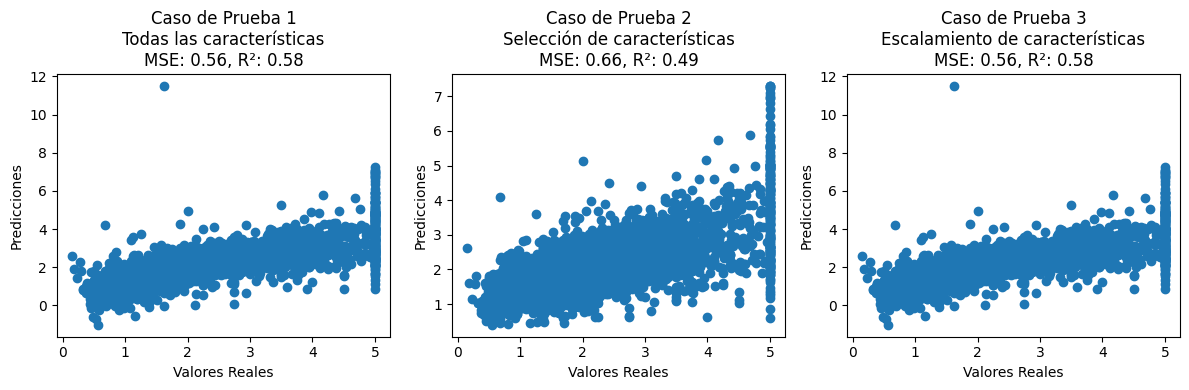

In [25]:

# Visualización de resultados
plt.figure(figsize=(12, 4))

# Gráfico para el Caso de Prueba 1
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_1)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Caso de Prueba 1\nTodas las características\nMSE: {:.2f}, R²: {:.2f}'.format(mse_1, r2_1))

# Gráfico para el Caso de Prueba 2
plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Caso de Prueba 2\nSelección de características\nMSE: {:.2f}, R²: {:.2f}'.format(mse_2, r2_2))

# Gráfico para el Caso de Prueba 3
plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred_3)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Caso de Prueba 3\nEscalamiento de características\nMSE: {:.2f}, R²: {:.2f}'.format(mse_3, r2_3))

plt.tight_layout()
plt.show()

In [26]:
import pandas as pd
california_housing = fetch_california_housing()
df=pd.DataFrame(california_housing.data,columns=california_housing.feature_names)

In [27]:
df['target']=california_housing.target
df.to_csv("california.csv")